# **6. Shortening protein sequences with ProtRL**

[ProtRL](https://github.com/AI4PDLab/ProtRL) repeatedly generates sequences, scores them, and updates a protein language model. Here will use a reward favours sequences close to 20 amino acids:

$$r(s)=-\left|20-|s|\right|$$

Iteration 1 is generated by the original model. Later iterations use the updated models, allowing us to follow the change in sequence length (online alignment).

> As usual, select **Runtime → Change runtime type → T4 GPU** before starting :)


## **1. Setup**


In [2]:
%pip uninstall -q -y torchao
%pip install -q -U transformers datasets peft accelerate trl pandas matplotlib
!git clone -q --depth 1 https://github.com/AI4PDLab/ProtRL.git /content/ProtRL


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 95.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import torch

assert torch.cuda.is_available(), "Select a GPU runtime and run again."

MODEL = "AI4PD/ProtGPT3-112M"
ITERATIONS = 6
OUTPUT = Path("/content/protrl_length")


**Exercise.** Why does six generation rounds correspond to only five observable model updates?


## **2. Inspect the reward**


In [4]:
def length_reward(sequence, target=20):
    return -abs(target - len(sequence))

for length in [20, 40, 80, 100]:
    print(length, length_reward("A" * length))


20 0
40 -20
80 -60
100 -80


**Exercise.** Which length receives the highest reward? Why are all other rewards negative?


## **3. Run the online loop**

Each iteration performs four operations:

1. generate 100 sequences;
2. record their lengths;
3. convert length into reward; and
4. update ProtGPT3 with ProtRL GRPO.

The first set is generated before any update and provides the baseline.


In [5]:
!cd /content/ProtRL && bash ProtRL.sh \
  --model_dir {MODEL} \
  --output_dir {OUTPUT} \
  --max_iteration_num {ITERATIONS}


Saving results to /content/protrl_length
RL for the enzyme class 1
Iteration 1
start
Sequence generation started
Using device: cuda
Loading model and tokenizer from AI4PD/ProtGPT3-112M...
config.json: 100% 778/778 [00:00<00:00, 3.45MB/s]
tokenizer_config.json: 100% 1.59k/1.59k [00:00<00:00, 953kB/s]
tokenizer.json: 100% 2.48k/2.48k [00:00<00:00, 8.36MB/s]
special_tokens_map.json: 100% 561/561 [00:00<00:00, 2.36MB/s]

model.safetensors: downloading bytes:  69% 150M/218M [00:02<00:00, 165MB/s, 10.9MB/s  ]
model.safetensors: downloading bytes:  86% 187M/218M [00:02<00:00, 172MB/s, 16.0MB/s  ]
model.safetensors: downloading bytes: 100% 187M/187M [00:02<00:00, 76.5MB/s, 17.3MB/s  ]
model.safetensors: reconstructing file: 100% 218M/218M [00:02<00:00, 89.1MB/s, 20.4MB/s  ]
Loading weights: 100% 75/75 [00:00<00:00, 372.95it/s]
generation_config.json: 100% 132/132 [00:00<00:00, 658kB/s]
Model loaded.
Generating 100 sequences for label: '1'
Computing metrics...
100% 100/100 [00:02<00:00, 38.86it

## **4. Measure the change**


In [6]:
logs = pd.read_csv(OUTPUT / "logs.csv")
summary = logs.groupby("iteration_num")["length"].agg(["mean", "std", "min", "max"])
summary.round(1)


,mean,std,min,max
iteration_num,,,,
1,92.4,15.8,18,100
2,75.2,22.9,27,100
3,51.4,18.2,12,100
4,36.0,10.6,9,75
5,27.7,8.7,13,67
6,24.0,8.3,8,57


**Exercise.** Compare the mean and standard deviation in the first and final iterations.


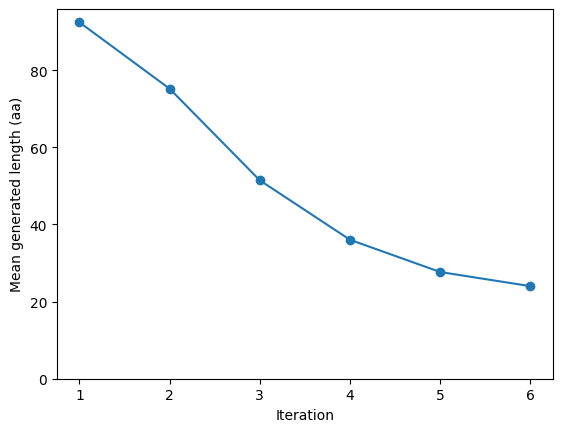

Change from first to final iteration: -68.4 aa


In [7]:
ax = summary["mean"].plot(marker="o", ylim=(0, None))
ax.set(xlabel="Iteration", ylabel="Mean generated length (aa)")
plt.show()

change = summary["mean"].iloc[-1] - summary["mean"].iloc[0]
print(f"Change from first to final iteration: {change:.1f} aa")


**Exercise.** Increase `ITERATIONS` to 8 in a fresh runtime. Does the mean approach 20 aa more closely?


## **Take-home messages**

- The model learns in an unsupervised fashion from pairs that are ordered according to a reward function.
- Online DPO creates preferences from fresh samples produced by the changing policy (this is why we call it online).
- Models can get really smart at hacking a property. This is called reward hacking (eg increase pLDDT by making sequences shorter)

**Sources**  Check our repo at: https://github.com/AI4PDLab/ProtRL/tree/main

